# Task 1: EDA and Preprocessing
CFPB Consumer Complaint Database: full dataset analysis and filtering
for the CrediTrust RAG chatbot project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 100)

FILTERED_PATH = "../data/processed/filtered_complaints.csv"

## 1. Load the full CFPB complaint dataset

The raw file is ~5GB / ~9.6M rows. We load it in chunks with progress
printed along the way, and only keep the columns we actually need.

In [2]:
RAW_PATH = "../data/raw/complaints.csv"   
USECOLS = [
    "Date received", "Product", "Sub-product", "Issue", "Sub-issue",
    "Consumer complaint narrative", "Company", "State", "Complaint ID",
]
DTYPES = {
    "Product": "category", "Sub-product": "category", "Issue": "category",
    "Sub-issue": "category", "Company": "category", "State": "category",
    "Complaint ID": "int64",
}

start = time.time()
chunks = []
chunk_size = 200_000

for i, chunk in enumerate(pd.read_csv(
    RAW_PATH, usecols=USECOLS, dtype=DTYPES,
    parse_dates=["Date received"], low_memory=False, chunksize=chunk_size,
)):
    chunks.append(chunk)
    print(f"Chunk {i+1}: {(i+1)*chunk_size:,} rows — {time.time()-start:.0f}s elapsed")

df = pd.concat(chunks, ignore_index=True)
del chunks
print(f"\nDone. {len(df):,} rows, {df.memory_usage(deep=True).sum()/1e9:.2f} GB, {time.time()-start:.0f}s total")
df.head()

Chunk 1: 200,000 rows — 1s elapsed
Chunk 2: 400,000 rows — 1s elapsed
Chunk 3: 600,000 rows — 2s elapsed
Chunk 4: 800,000 rows — 3s elapsed
Chunk 5: 1,000,000 rows — 4s elapsed
Chunk 6: 1,200,000 rows — 5s elapsed
Chunk 7: 1,400,000 rows — 6s elapsed
Chunk 8: 1,600,000 rows — 7s elapsed
Chunk 9: 1,800,000 rows — 7s elapsed
Chunk 10: 2,000,000 rows — 8s elapsed
Chunk 11: 2,200,000 rows — 9s elapsed
Chunk 12: 2,400,000 rows — 10s elapsed
Chunk 13: 2,600,000 rows — 11s elapsed
Chunk 14: 2,800,000 rows — 12s elapsed
Chunk 15: 3,000,000 rows — 13s elapsed
Chunk 16: 3,200,000 rows — 14s elapsed
Chunk 17: 3,400,000 rows — 15s elapsed
Chunk 18: 3,600,000 rows — 17s elapsed
Chunk 19: 3,800,000 rows — 18s elapsed
Chunk 20: 4,000,000 rows — 19s elapsed
Chunk 21: 4,200,000 rows — 20s elapsed
Chunk 22: 4,400,000 rows — 22s elapsed
Chunk 23: 4,600,000 rows — 23s elapsed
Chunk 24: 4,800,000 rows — 24s elapsed
Chunk 25: 5,000,000 rows — 25s elapsed
Chunk 26: 5,200,000 rows — 27s elapsed
Chunk 27: 5,40

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company,State,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Experian Information Solutions Inc.,FL,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,"Eastern Account Systems of Connecticut, Inc.",FL,14195688
2,2025-06-20,Credit reporting or other personal consumer reports,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,14195689
3,2025-06-20,Credit reporting or other personal consumer reports,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,Experian Information Solutions Inc.,AZ,14195690
4,2025-06-20,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,Experian Information Solutions Inc.,IL,14195692


## 2. Initial EDA

### 2a. Distribution of complaints across products

In [3]:
product_counts = df["Product"].value_counts()
print(product_counts)

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

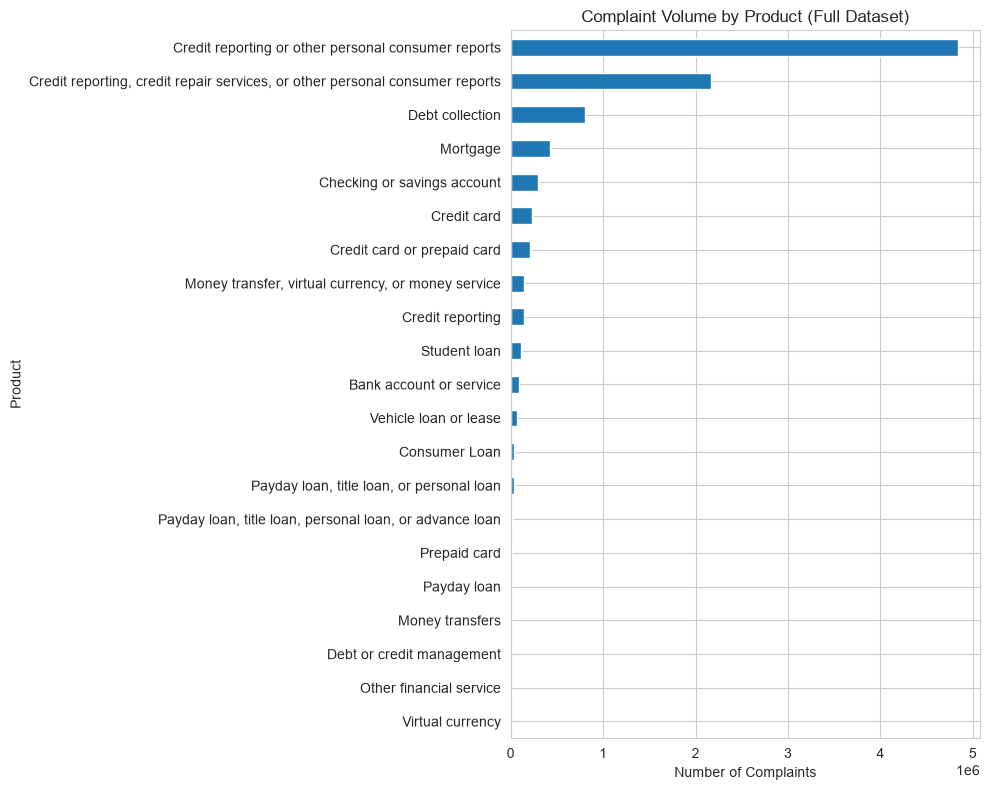

In [4]:
plt.figure(figsize=(10, 8))
product_counts.plot(kind="barh")
plt.xlabel("Number of Complaints")
plt.title("Complaint Volume by Product (Full Dataset)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../data/processed/eda_product_distribution.png", dpi=150)
plt.show()

### 2b. Consumer narrative length (word count)

We compute word count only where a narrative exists, to avoid NaN issues.
With ~9.6M total rows, we use a plain numpy loop rather than chained
`.str` accessors for speed.

In [5]:
has_narrative = df["Consumer complaint narrative"].notna()
print(f"With narrative:    {has_narrative.sum():,}")
print(f"Without narrative: {(~has_narrative).sum():,}")
print(f"Percentage with:   {has_narrative.mean()*100:.1f}%")

With narrative:    2,980,756
Without narrative: 6,629,041
Percentage with:   31.0%


In [6]:
start = time.time()
narratives = df.loc[has_narrative, "Consumer complaint narrative"].to_numpy()
word_counts = np.array([len(str(n).split()) for n in narratives])
print(pd.Series(word_counts).describe())
print(f"\n{time.time()-start:.1f}s")

count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
dtype: float64

39.5s


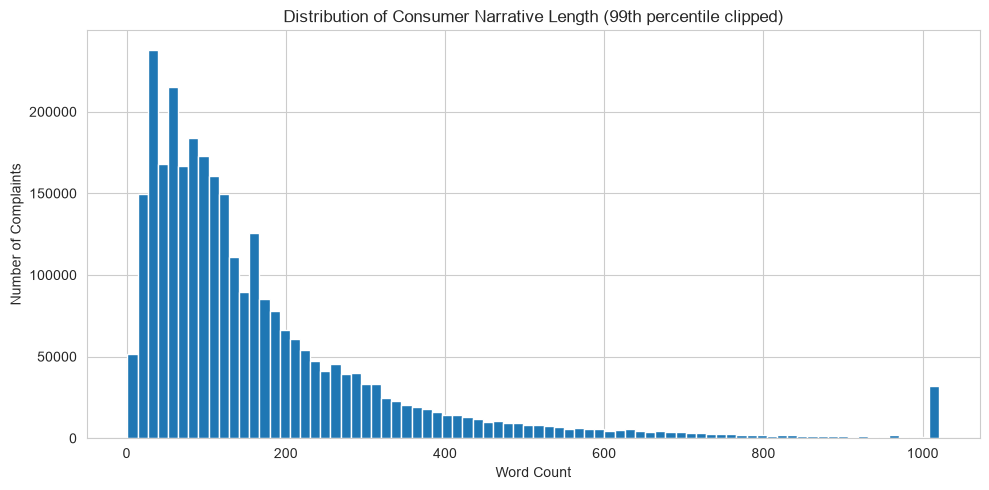

In [7]:
plt.figure(figsize=(10, 5))
clipped = np.clip(word_counts, None, np.percentile(word_counts, 99))
plt.hist(clipped, bins=80)
plt.xlabel("Word Count")
plt.ylabel("Number of Complaints")
plt.title("Distribution of Consumer Narrative Length (99th percentile clipped)")
plt.tight_layout()
plt.savefig("../data/processed/eda_narrative_length.png", dpi=150)
plt.show()

In [8]:
print("Very short narratives (<5 words):", (word_counts < 5).sum())
print("Very long narratives (>1000 words):", (word_counts > 1000).sum())

Very short narratives (<5 words): 3175
Very long narratives (>1000 words): 32428


### 2c. Count complaints with and without narratives (by product)
Useful to see whether narrative availability skews by product category.

In [9]:
narrative_by_product = (
    df.assign(has_narrative=has_narrative)
    .groupby("Product", observed=True)["has_narrative"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "with_narrative", "count": "total"})
)
narrative_by_product["pct_with_narrative"] = (
    narrative_by_product["with_narrative"] / narrative_by_product["total"] * 100
).round(1)
narrative_by_product.sort_values("total", ascending=False)

,with_narrative,total,pct_with_narrative
Product,,,
Credit reporting or other personal consumer reports,1091253,4834855,22.6
"Credit reporting, credit repair services, or other personal consumer reports",807281,2163857,37.3
Debt collection,336076,799197,42.1
Mortgage,130160,422254,30.8
Checking or savings account,140319,291178,48.2
Credit card,80667,226686,35.6
Credit card or prepaid card,108667,206369,52.7
"Money transfer, virtual currency, or money service",97188,145066,67.0
Credit reporting,31587,140429,22.5


## 3. Filter the dataset

First, inspect the *exact* unique Product values present in this export.
CFPB has renamed categories over the years, so we match flexibly rather
than assuming exact strings.

In [10]:
print(sorted(df["Product"].unique().tolist()))

['Bank account or service', 'Checking or savings account', 'Consumer Loan', 'Credit card', 'Credit card or prepaid card', 'Credit reporting', 'Credit reporting or other personal consumer reports', 'Credit reporting, credit repair services, or other personal consumer reports', 'Debt collection', 'Debt or credit management', 'Money transfer, virtual currency, or money service', 'Money transfers', 'Mortgage', 'Other financial service', 'Payday loan', 'Payday loan, title loan, or personal loan', 'Payday loan, title loan, personal loan, or advance loan', 'Prepaid card', 'Student loan', 'Vehicle loan or lease', 'Virtual currency']


Based on the unique values above, the following maps each of the 4 target
categories to the matching raw `Product` label(s), using the mapping
defined in `src/preprocessing.py`. We include the standalone `"Payday
loan"` label under Personal Loan alongside the bundled payday/title/
personal-loan variants.

In [11]:
import sys
sys.path.insert(0, "..")

from src.preprocessing import (
    PRODUCT_MAP,
    build_reverse_product_map,
    get_target_raw_products,
    clean_text,
)

target_products = get_target_raw_products()
reverse_map = build_reverse_product_map()

filtered = df[df["Product"].isin(target_products)].copy()
filtered["product_category"] = filtered["Product"].map(reverse_map)

print(f"Rows after product filter: {len(filtered):,}")
print(filtered["product_category"].value_counts())

Rows after product filter: 1,045,128
product_category
Credit Card        433055
Savings Account    377383
Money Transfer     150420
Personal Loan       84270
Name: count, dtype: int64


In [12]:
filtered = filtered[filtered["Consumer complaint narrative"].notna()].copy()
filtered = filtered[filtered["Consumer complaint narrative"].str.strip() != ""]

print(f"Rows after dropping empty narratives: {len(filtered):,}")
print(filtered["product_category"].value_counts())

Rows after dropping empty narratives: 480,564
product_category
Credit Card        189334
Savings Account    155204
Money Transfer      98685
Personal Loan       37341
Name: count, dtype: int64


## 4. Clean the text narratives

Uses `clean_text()` from `src/preprocessing.py`, which applies:
1. Lowercasing, URL/phone/ID/HTML/redaction removal, punctuation stripping
2. Tokenization, stopword removal, and lemmatization (verbs + nouns)

This step is the slowest in the pipeline since NLTK tokenization and
lemmatization run in pure Python but it's now applied only to the
filtered subset, not the full 9.6M rows.

In [13]:
start = time.time()
filtered["cleaned_narrative"] = filtered["Consumer complaint narrative"].apply(clean_text)
print(f"{time.time()-start:.1f}s for {len(filtered):,} rows")

# Drop any rows that became empty after cleaning
filtered = filtered[filtered["cleaned_narrative"].str.len() > 0]

print(f"Final row count: {len(filtered):,}")
filtered[["Consumer complaint narrative", "cleaned_narrative"]].head(3)

632.1s for 480,564 rows
Final row count: 480,560


,Consumer complaint narrative,cleaned_narrative
12237,A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX that an...,card open name fraudster receive notice account open name reach state activity unauthorized conf...
12532,I made the mistake of using my wellsfargo debit card to depsit funds Into XXXXXXXX ATM machine o...,make mistake use wellsfargo debit card depsit fund atm machine outside branch go branch tell cou...
13280,"Dear CFPB, I have a secured credit card with citibank which is changed to unsecured card and I h...",dear cfpb secure credit card citibank change unsecured card call n waitting check release secure...


## 5. Save the cleaned and filtered dataset

In [14]:
output_cols = [
    "Complaint ID", "Date received", "product_category", "Product",
    "Sub-product", "Issue", "Sub-issue", "Company", "State",
    "Consumer complaint narrative", "cleaned_narrative",
]

filtered[output_cols].to_csv(FILTERED_PATH, index=False)
print(f"Saved {len(filtered):,} rows to {FILTERED_PATH}")

Saved 480,560 rows to ../data/processed/filtered_complaints.csv



**EDA Summary**

The full CFPB complaint dataset contains 9,609,797 records spanning all CFPB product categories. Only 31.0% of complaints (2,980,756) include a free-text consumer narrative; the remaining 69% were submitted without one, meaning the bulk of the raw dataset is unusable for a narrative-based RAG system. Among complaints with narratives, length is right-skewed: the median is 114 words and the mean is 176 words, with a long tail extending to a maximum of 6,469 words.
After filtering to the four target product categories (Credit Card, Personal Loan, Savings Account, Money Transfer) and removing records with empty narratives, the dataset was reduced to 480,564 complaints. Distribution across categories is uneven. Credit Card (189,334) and Savings Account (155,204) dominate, while Money Transfer (98,685) and especially Personal Loan (37,341) are comparatively underrepresented, a roughly 5:1 ratio between the largest and smallest category that should inform stratified sampling in Task 2.
Narratives were cleaned in two stages: noise removal (lowercasing, stripping URLs, phone numbers, HTML tags, CFPB redaction placeholders, and punctuation) followed by NLP normalization (tokenization, English stopword removal, and lemmatization of both verbs and nouns). This pipeline ran in 632 seconds across 480,564 rows and removed only 4 records that became empty after cleaning, indicating the original narratives were almost universally substantive. The cleaned dataset was saved to data/filtered_complaints.csv for use in Task 2.